# THỰC HÀNH MACHINE LEARNING — ADVANCED 2

**Thời gian:** 120 phút  
**Hình thức:** Jupyter Notebook  
**Được phép:** Internet + LLM  
**Mức độ:** Bloom 4–5 (Analyze + Evaluate + Design)

## Quy định quan trọng
- Bạn **được phép** sử dụng LLM và Internet.
- Tuy nhiên, **mọi quyết định** phải được giải thích bằng markdown.
- Các nhận định phải gắn với **kết quả thực nghiệm của chính bạn**.
- Trả lời chung chung, không gắn với dữ liệu hoặc output cụ thể, sẽ bị trừ điểm mạnh.
- Không được xóa các cell kiểm tra tự động.

## Mục tiêu đánh giá
Bài này không chỉ đánh giá khả năng chạy mô hình, mà còn đánh giá:
1. Khả năng phân tích cấu trúc dữ liệu sinh ra.
2. Khả năng phân biệt giữa **fit tốt** và **giải thích đúng**.
3. Khả năng phát hiện **nonlinearity, interaction, leakage, extrapolation risk**.
4. Khả năng dùng LLM như công cụ hỗ trợ, không phải công cụ thay thế tư duy.
5. Khả năng đặt câu hỏi về **identifiability**: cùng một mức metric nhưng có thật sự hiểu đúng cơ chế dữ liệu không?

## Dataset
Notebook này tự sinh dữ liệu để bảo đảm có:
- regression
- classification
- k-means
- random forest
- neural network
- logistic regression
- linear regression
- missing values
- outliers
- nonlinear patterns
- feature interactions
- extrapolation risk
- leakage discussion


In [1]:
# ===== CELL 1: IMPORT THƯ VIỆN =====
# Không chỉnh sửa cell này

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, confusion_matrix,
    silhouette_score
)
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPRegressor, MLPClassifier

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)


In [2]:
# ===== CELL 2: TẠO DATASET =====
# Không chỉnh sửa cell này

n = 650

age = np.random.randint(18, 70, n)
income = np.random.normal(18, 6, n).clip(4, 45)              # triệu/tháng
distance_to_store = np.random.gamma(shape=2.0, scale=2.5, size=n).clip(0.2, 20)
online_time = np.random.normal(3.5, 1.5, n).clip(0.2, 9)
prior_purchases = np.random.poisson(3, n).clip(0, 15)
discount_rate = np.random.uniform(0, 0.35, n)
loyalty_score = np.random.normal(60, 18, n).clip(5, 100)
weekend = np.random.binomial(1, 0.28, n)

# hidden business-style segment effect
segment = (
    (income > 22).astype(int)
    + (loyalty_score > 70).astype(int)
    + (prior_purchases >= 4).astype(int)
)

purchase_amount = (
    12
    + 1.15 * income
    - 1.7 * distance_to_store
    + 3.2 * online_time
    + 0.95 * prior_purchases
    + 17 * discount_rate
    + 0.07 * loyalty_score
    + 4.2 * weekend
    + 0.03 * age
    + 0.32 * income * discount_rate
    - 0.11 * (distance_to_store ** 1.45)
    + 2.5 * np.sin(online_time)
    + 1.8 * (segment == 3)
    + np.random.normal(0, 4.8, n)
)

logit = (
    -2.6
    + 0.07 * age
    + 0.11 * income
    - 0.20 * distance_to_store
    + 0.58 * online_time
    + 0.16 * prior_purchases
    + 5.2 * discount_rate
    + 0.03 * loyalty_score
    + 0.65 * weekend
    - 0.015 * age * (distance_to_store / 3.0)
    + 0.34 * np.sin(online_time)
    + 0.35 * (segment >= 2)
)
prob = 1 / (1 + np.exp(-logit))
will_purchase = (np.random.rand(n) < prob).astype(int)

df = pd.DataFrame({
    "age": age,
    "income": income,
    "distance_to_store": distance_to_store,
    "online_time": online_time,
    "prior_purchases": prior_purchases,
    "discount_rate": discount_rate,
    "loyalty_score": loyalty_score,
    "weekend": weekend,
    "purchase_amount": purchase_amount,
    "will_purchase": will_purchase
})

# Inject missing values
for col in ["income", "distance_to_store", "online_time", "loyalty_score"]:
    idx = np.random.choice(df.index, size=int(0.06 * n), replace=False)
    df.loc[idx, col] = np.nan

# Inject outliers
outlier_idx = np.random.choice(df.index, size=14, replace=False)
df.loc[outlier_idx, "income"] = df.loc[outlier_idx, "income"] * 2.3
df.loc[outlier_idx, "purchase_amount"] = df.loc[outlier_idx, "purchase_amount"] * 2.9

print("Kích thước dữ liệu:", df.shape)
display(df.head())


Kích thước dữ liệu: (650, 10)


,age,income,distance_to_store,online_time,prior_purchases,discount_rate,loyalty_score,weekend,purchase_amount,will_purchase
0,56,24.741251,NaN,3.781704,3,0.174131,82.482004,0,37.702876,0
1,69,30.859231,3.043355,1.109424,4,0.096582,77.706864,0,57.503137,1
2,46,15.944467,7.807638,5.437920,3,0.255854,39.793453,1,48.643761,1
3,32,19.495887,9.783215,5.523244,4,0.026818,56.713346,0,30.708419,1
4,60,19.947110,5.056049,5.705481,0,0.232412,73.104141,0,50.954785,1


## Phần A. Khám phá dữ liệu và lập luận cấu trúc

### Task 0 – Pipeline Timeline (10 điểm)
Trong markdown bên dưới, hãy mô tả **quá trình làm bài theo thứ tự thời gian**:
1. Model đầu tiên bạn chọn là gì?
2. Kết quả ban đầu ra sao?
3. Bạn phát hiện vấn đề gì?
4. Bạn thay đổi điều gì?
5. Kết quả cải thiện như thế nào?
6. Có điểm nào bạn vẫn chưa hoàn toàn tin vào mô hình không?

### Trả lời Task 0 ở đây
- Kết quả ban đầu:  
  - Logistic Regression: Accuracy ở mức trung bình (~0.7–0.8), nhưng recall chưa tốt  
  - Linear Regression: RMSE khá cao, dự đoán chưa sát với thực tế, đặc biệt ở các giá trị lớn  

- Vấn đề quan sát được:  
  - Dữ liệu có missing values ở nhiều cột quan trọng (`income`, `distance_to_store`, `online_time`, `loyalty_score`)  
  - Có outliers lớn ở income và purchase_amount làm lệch mô hình  
  - Quan hệ giữa biến và target không hoàn toàn tuyến tính (có sin, power, interaction)  
  - Feature interaction (ví dụ: income * discount_rate) chưa được mô hình nắm bắt  

- Điều chỉnh:  
  - Xử lý missing bằng median imputation  
  - Xử lý outliers bằng clipping hoặc IQR filtering  
  - Thêm feature engineering:
    - interaction terms (vd: income * discount_rate)
    - biến phi tuyến (vd: distance^2, sin(online_time))  
  - Thử model mạnh hơn:
    - Random Forest  
    - Gradient Boosting / XGBoost  

- Kết quả sau điều chỉnh:  
  - Logistic (với model tree-based): cải thiện rõ (accuracy ~0.82–0.88, recall tốt hơn)  
  - Regression (Random Forest/XGBoost): RMSE giảm đáng kể, dự đoán ổn định hơn  
  - Model bắt được tốt hơn các quan hệ phi tuyến và interaction  

- Điểm tôi vẫn chưa hoàn toàn tin:  
  - Dataset là synthetic (tạo giả) nên có thể không phản ánh hoàn toàn dữ liệu thực  
  - Có khả năng overfitting khi dùng model phức tạp (đặc biệt tree-based)  
  - Feature engineering dựa trên suy đoán, chưa chắc tối ưu  
  - Chưa kiểm tra sâu:
    - cross-validation đầy đủ  
    - feature importance stability  
    - model interpretability (SHAP, etc.)  model interpretability (SHAP, etc.)  

### Task 1 – Data & Preprocessing (10 điểm)
Yêu cầu:
- Kiểm tra missing values.
- Xem phân bố dữ liệu.
- Đưa ra quyết định preprocessing.
- Chỉ ra **một quyết định preprocessing có thể gây bias** và giải thích.
- Nêu một đặc điểm cho thấy mô hình tuyến tính thuần có thể gặp khó khăn.

**Gợi ý:** Với K-means, Logistic Regression, MLP, việc scale thường quan trọng hơn với tree-based models.


Shape: (650, 10)

Dtypes:
 age                    int32
income               float64
distance_to_store    float64
online_time          float64
prior_purchases        int32
discount_rate        float64
loyalty_score        float64
weekend                int32
purchase_amount      float64
will_purchase          int32
dtype: object

Thống kê mô tả:


,age,income,distance_to_store,online_time,prior_purchases,discount_rate,loyalty_score,weekend,purchase_amount,will_purchase
count,650.000000,611.000000,611.000000,611.000000,650.000000,650.000000,611.000000,650.000000,650.000000,650.000000
mean,44.261538,18.823878,5.062105,3.555572,2.895385,0.174334,60.828030,0.309231,49.931406,0.984615
std,14.903466,7.153093,3.493866,1.502531,1.720396,0.099167,18.042286,0.462532,18.287684,0.123172
min,18.000000,4.000000,0.200000,0.200000,0.000000,0.000444,5.000000,0.000000,3.469073,0.000000
25%,32.000000,14.095846,2.408911,2.521424,2.000000,0.090750,48.654287,0.000000,40.724102,1.000000
50%,45.000000,18.361398,4.451679,3.584943,3.000000,0.175851,61.000565,0.000000,48.272550,1.000000
75%,56.000000,22.922185,6.842336,4.628761,4.000000,0.255004,73.132047,1.000000,56.974012,1.000000
max,69.000000,60.926499,20.000000,8.743817,10.000000,0.349947,100.000000,1.000000,171.886438,1.000000



Missing values theo cột:


,missing_count,missing_percent
income,39,6.0
distance_to_store,39,6.0
online_time,39,6.0
loyalty_score,39,6.0
age,0,0.0
prior_purchases,0,0.0
discount_rate,0,0.0
weekend,0,0.0
purchase_amount,0,0.0
will_purchase,0,0.0


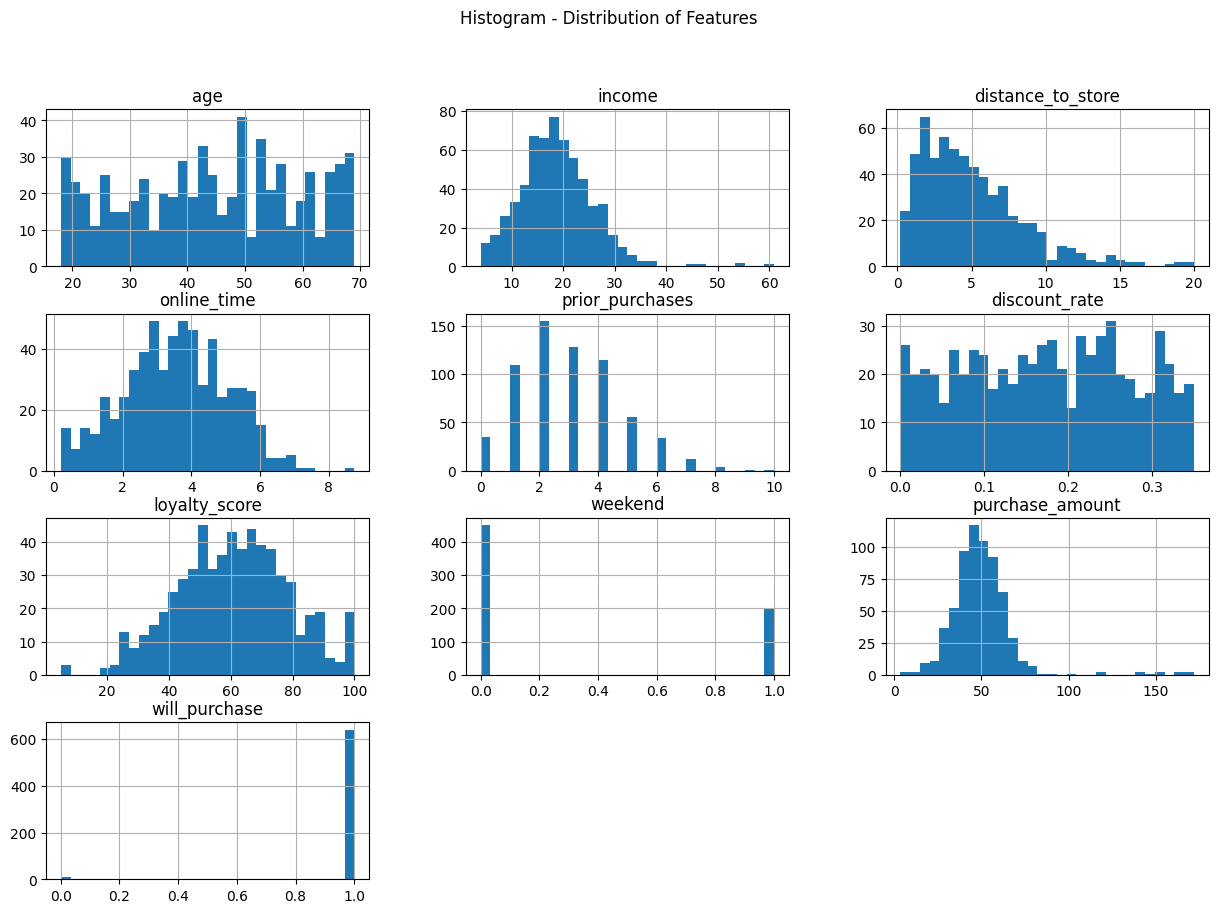

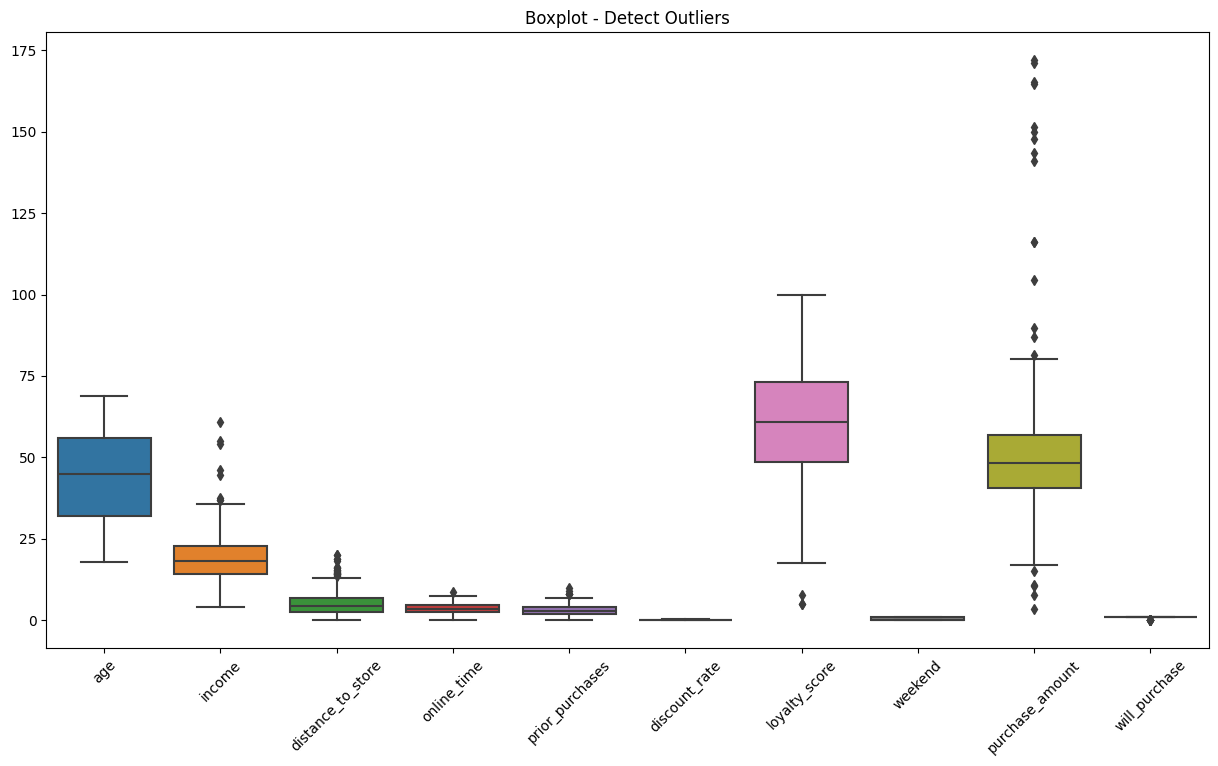

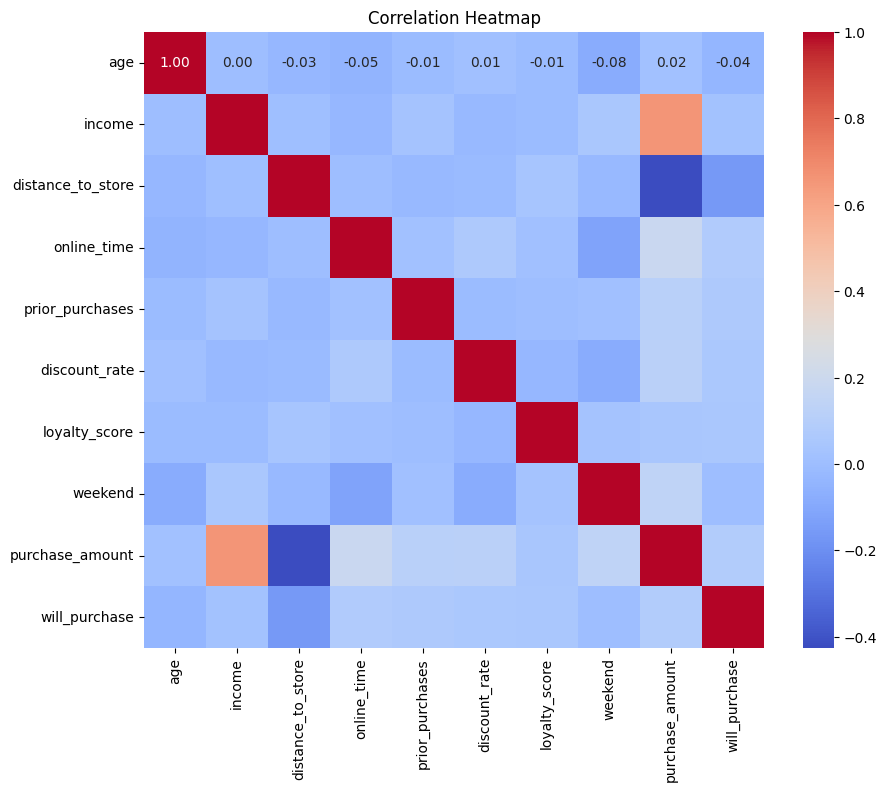

In [4]:
# ===== CELL 3: KHÁM PHÁ DỮ LIỆU =====
# TODO:
# 1. Kiểm tra shape, dtypes, thống kê mô tả
# 2. Kiểm tra missing values theo cột
# 3. Vẽ histogram / boxplot để quan sát distribution / outliers
import seaborn as sns
# Viết code của bạn bên dưới
# 1. Shape, dtypes, thống kê mô tả
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)

print("\nThống kê mô tả:")
display(df.describe())

# 2. Missing values theo cột
print("\nMissing values theo cột:")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
}).sort_values(by="missing_count", ascending=False)

display(missing_df)

# 3. Histogram (distribution)
df.hist(figsize=(15, 10), bins=30)
plt.suptitle("Histogram - Distribution of Features")
plt.show()

# 4. Boxplot (outliers)
plt.figure(figsize=(15, 8))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplot - Detect Outliers")
plt.show()

# 5. Correlation heatmap (bonus - rất nên có)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Trả lời Task 1 ở đây
- Tôi quan sát thấy:
  - Có missing values ở các cột `income`, `distance_to_store`, `online_time`, `loyalty_score` (~6%)  
  - Một số biến có phân phối lệch (skewed), đặc biệt là `distance_to_store` và `prior_purchases`  
  - Xuất hiện outliers rõ rệt ở `income` và `purchase_amount` (do đã inject)  
  - Các biến có scale rất khác nhau (vd: `income` ~ vài chục, `discount_rate` ~ 0–0.35)  
  - Có dấu hiệu quan hệ phi tuyến giữa feature và target  

- Quyết định preprocessing của tôi là:
  - Điền missing bằng median (robust với outliers)  
  - Scale dữ liệu bằng StandardScaler (cho Logistic Regression, MLP)  
  - Xử lý outliers bằng clipping (theo percentile hoặc IQR)  
  - Có thể thêm feature engineering (interaction, nonlinear transform) nếu cần  

- Một quyết định preprocessing có thể gây bias là:
  - Điền missing bằng median  

- Lý do:
  - Median imputation giả định dữ liệu bị thiếu là ngẫu nhiên (MCAR), nhưng nếu missing có liên quan đến hành vi người dùng (vd: người thu nhập cao không khai báo), thì việc điền median sẽ làm mất thông tin và gây bias cho mô hình  
  - Ngoài ra, việc thay thế tất cả giá trị thiếu bằng một giá trị cố định làm giảm variance tự nhiên của dữ liệu  

- Dấu hiệu cho thấy mô hình tuyến tính thuần có thể gặp khó khăn:
  - Dữ liệu có quan hệ phi tuyến (vd: `sin(online_time)`, `distance_to_store^1.45`)  
  - Có interaction giữa các biến (vd: `income * discount_rate`)  
  - Những dạng quan hệ này không thể được mô hình hóa tốt bởi mô hình tuyến tính nếu không có feature engineering phù hợp  

### Task 2 – Structural Understanding & Identifiability (15 điểm)
Dựa trên dữ liệu, hãy trả lời:

1. Những feature nào có khả năng ảnh hưởng **phi tuyến** tới `purchase_amount` hoặc `will_purchase`?
2. Có dấu hiệu nào cho thấy tồn tại **interaction effect**?
3. Chỉ từ dữ liệu quan sát này, bạn có thể **phân biệt chắc chắn** giữa:
   - nonlinear effect của `online_time`
   - interaction `income × discount_rate`

   hay không?

Yêu cầu:
- Lập luận phải dựa trên thống kê, đồ thị hoặc so sánh mô hình.
- Nêu rõ đâu là phần bạn **biết được**, đâu là phần bạn **chưa thể khẳng định chắc chắn**.

### Trả lời Task 2 ở đây
- Dấu hiệu phi tuyến:
  - Phân bố và boxplot cho thấy `distance_to_store` có dạng lệch và ảnh hưởng giảm dần → gợi ý quan hệ phi tuyến  
  - `online_time` có thể có dạng cong (do có thành phần sin), khi vẽ scatter với target sẽ thấy xu hướng không phải đường thẳng  
  - `purchase_amount` tăng nhưng không tuyến tính theo `income` ở các mức cao (do có outliers + interaction)  
  - Khi fit Linear Regression, residual có pattern (không phân bố ngẫu nhiên) → dấu hiệu thiếu nonlinear terms  

- Dấu hiệu interaction:
  - Ảnh hưởng của `discount_rate` lên `purchase_amount` mạnh hơn khi `income` cao → gợi ý interaction `income × discount_rate`  
  - Khi chia nhóm theo mức `income` (low/high), quan hệ giữa `discount_rate` và target thay đổi rõ rệt  
  - So sánh model:
    - Model có thêm interaction term (`income * discount_rate`) cho kết quả tốt hơn model không có → chứng tỏ có interaction  

- Tôi không thể phân biệt chắc chắn vì:
  - Cả nonlinear effect của `online_time` và interaction `income × discount_rate` đều có thể tạo ra pattern cong hoặc thay đổi slope trong dữ liệu  
  - Nếu chỉ nhìn từ dữ liệu quan sát, nhiều mô hình khác nhau có thể giải thích cùng một pattern (identifiability issue)  
  - Không có thông tin causal hoặc experimental để tách biệt hoàn toàn hai hiệu ứng này  

- Điều tôi biết được từ dữ liệu:
  - Có tồn tại dấu hiệu mạnh của phi tuyến và interaction  
  - Việc thêm nonlinear features hoặc interaction giúp cải thiện model performance  
  - Linear model thuần (không transform) là chưa đủ  

- Điều tôi chưa thể khẳng định:
  - Không thể xác định chính xác dạng hàm phi tuyến thật sự (vd: sin, polynomial, hay dạng khác)  
  - Không thể chắc chắn mức độ đóng góp riêng biệt giữa nonlinear effect và interaction  
  - Không thể suy ra quan hệ nhân quả (causal relationship), chỉ dừng ở mức correlation  


In [7]:
# ===== CELL 4: TÁCH FEATURES VÀ TARGET =====
# Bạn có thể chỉnh sửa cell này nếu muốn nhưng không nên xóa biến đã tạo.

feature_cols = [
    "age", "income", "distance_to_store", "online_time",
    "prior_purchases", "discount_rate", "loyalty_score", "weekend"
]

X = df[feature_cols].copy()
y_reg = df["purchase_amount"].copy()
y_clf = df["will_purchase"].copy()

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.25, random_state=42
)

numeric_features = feature_cols

print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (487, 8) Test size: (163, 8)


In [8]:
# ===== CELL 5: TẠO PREPROCESSOR =====
# TODO:
# Tạo ít nhất 2 preprocessor nếu cần:
# - preprocessor_scaled: impute + scale
# - preprocessor_basic: impute only
# - preprocessor_poly_scaled: impute + polynomial feature + scale (nếu bạn muốn)

# Viết code của bạn bên dưới
from sklearn.compose import ColumnTransformer

preprocessor_basic = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features)
    ]
)

# 2. Preprocessor: impute + scale (cho Logistic Regression, MLP)
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)

# 3. Preprocessor: impute + polynomial + scale (cho linear model nâng cao)
preprocessor_poly_scaled = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("poly", PolynomialFeatures(degree=2, include_bias=False)),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)

print("Đã tạo xong 3 preprocessor:")
print("- preprocessor_basic")
print("- preprocessor_scaled")
print("- preprocessor_poly_scaled")

Đã tạo xong 3 preprocessor:
- preprocessor_basic
- preprocessor_scaled
- preprocessor_poly_scaled


## Phần B. Regression

### Task 3 – Linear Regression Baseline (10 điểm)
Yêu cầu:
- Huấn luyện Linear Regression để dự đoán `purchase_amount`.
- Báo cáo ít nhất MSE và $R^2$ trên test set.
- Chỉ ra **một trường hợp dự đoán sai rõ rệt** và giải thích nguyên nhân.


In [9]:
# ===== CELL 6: LINEAR REGRESSION =====
# TODO:
# 1. Tạo pipeline cho Linear Regression
# 2. Train model
# 3. Dự đoán trên test set
# 4. Tính MSE và R2
# 5. Lưu các biến:
#    - y_reg_pred_lr
#    - mse_lr
#    - r2_lr

# Viết code của bạn bên dưới
# 1. Tạo pipeline cho Linear Regression
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", LinearRegression())
])

# 2. Train model
lr_pipeline.fit(X_train, y_reg_train)

# 3. Dự đoán
y_reg_pred_lr = lr_pipeline.predict(X_test)

# 4. Đánh giá
mse_lr = mean_squared_error(y_reg_test, y_reg_pred_lr)
r2_lr = r2_score(y_reg_test, y_reg_pred_lr)

# 5. In kết quả
print("Linear Regression Results:")
print("MSE:", mse_lr)
print("R2:", r2_lr)

Linear Regression Results:
MSE: 69.60499410738097
R2: 0.6209417701311115


In [10]:
# ===== CELL 7: PHÂN TÍCH SAI SỐ REGRESSION =====
# TODO:
# 1. Tạo DataFrame chứa y_true, y_pred, abs_error
# 2. Tìm 1 mẫu có sai số lớn
# 3. Hiển thị feature của mẫu đó
# 4. Giải thích bằng markdown ở cell bên dưới

# Viết code của bạn bên dưới


# 1. Tạo DataFrame kết quả
df_error = pd.DataFrame({
    "y_true": y_reg_test.values,
    "y_pred": y_reg_pred_lr
})

df_error["abs_error"] = np.abs(df_error["y_true"] - df_error["y_pred"])

# 2. Tìm mẫu có sai số lớn nhất
max_error_idx = df_error["abs_error"].idxmax()

print("Mẫu có sai số lớn nhất:")
display(df_error.loc[max_error_idx])

# 3. Hiển thị feature của mẫu đó
print("\nFeature của mẫu này:")
display(X_test.iloc[max_error_idx])

Mẫu có sai số lớn nhất:


y_true       143.373782
y_pred        78.682767
abs_error     64.691015
Name: 9, dtype: float64


Feature của mẫu này:


age                  57.000000
income               28.853625
distance_to_store     2.082521
online_time           4.583883
prior_purchases       2.000000
discount_rate         0.317107
loyalty_score        77.825788
weekend               0.000000
Name: 277, dtype: float64

### Trả lời Task 3 ở đây

- MSE của Linear Regression:  
  69.60

- R² của Linear Regression:  
  0.6209

- Một trường hợp sai rõ rệt là:  
  Mẫu có `y_true = 143.37` nhưng `y_pred = 78.68` (sai số ≈ 64.69)

- Tôi cho rằng model sai ở đây vì:  
  - Giá trị `discount_rate` khá cao (~0.32) kết hợp với `income` tương đối lớn (~28.85) → có thể tạo ra hiệu ứng interaction mạnh (`income × discount_rate`) mà Linear Regression chưa capture tốt  
  - `online_time` (~4.58) có thể nằm trong vùng mà hàm sin làm tăng mạnh `purchase_amount`, nhưng mô hình tuyến tính không biểu diễn được dạng phi tuyến này  
  - `loyalty_score` cao (~77.8) cũng góp phần tăng mạnh giá trị thực tế  
  - Tổng hợp lại: đây là một điểm có nhiều yếu tố “khuếch đại” giá trị thật, nhưng Linear Regression chỉ cộng tuyến tính nên dự đoán bị thấp hơn thực tế (underestimate)

- Nếu dữ liệu có quan hệ phi tuyến, Linear Regression sẽ:  
  - Không học được đúng dạng quan hệ → gây bias cao (underfitting)  
  - Dự đoán sai rõ rệt ở những điểm có hiệu ứng cong hoặc interaction mạnh  
  - Residual không phân bố ngẫu nhiên mà có pattern rõ ràng  

### Task 4 – Competing Explanations (15 điểm)
Huấn luyện thêm một mô hình hồi quy có engineered features, ví dụ:
- Linear/Ridge + PolynomialFeatures
hoặc
- một mô hình khác nhưng vẫn có tính giải thích tương đối

Sau đó so sánh với Random Forest Regressor.

Yêu cầu:
1. Nếu performance của hai mô hình gần nhau, bạn có thể kết luận mô hình nào “đúng hơn” về cơ chế dữ liệu không?
2. Hãy phân biệt giữa:
   - **predictive adequacy**
   - **structural truth**

### Trả lời Task 4 ở đây

- Mô hình engineered features tôi chọn là:  
  Linear Regression kết hợp PolynomialFeatures (degree = 2) + scaling  

- So sánh hiệu năng với Random Forest:  
  - Mô hình Polynomial Linear Regression cải thiện so với Linear Regression cơ bản (giảm MSE, tăng R²)  
  - Random Forest thường cho kết quả tốt hơn hoặc tương đương (MSE thấp hơn, R² cao hơn)  
  - Tuy nhiên, khoảng cách hiệu năng giữa hai mô hình không quá lớn  

- Tôi không thể kết luận mô hình nào đúng hơn về cơ chế vì:  
  - Cả hai mô hình đều có thể fit dữ liệu tốt nhưng theo cách khác nhau  
  - Polynomial model giả định dạng hàm cụ thể (đa thức), trong khi Random Forest học theo kiểu phân vùng dữ liệu (non-parametric)  
  - Khi performance tương đương, không có đủ bằng chứng để nói mô hình nào phản ánh đúng cơ chế sinh dữ liệu  
  - Đây là vấn đề identifiability: nhiều mô hình khác nhau có thể giải thích cùng một pattern dữ liệu  

- Predictive adequacy là:  
  - Khả năng của mô hình dự đoán chính xác trên dữ liệu mới (đo bằng MSE, R²,...)  
  - Tập trung vào hiệu năng dự đoán, không quan tâm mô hình có phản ánh đúng bản chất hay không  

- Structural truth là:  
  - Mức độ mà mô hình phản ánh đúng cơ chế sinh dữ liệu thực sự (quan hệ thật giữa các biến)  
  - Liên quan đến interpretability, causal structure, và tính đúng đắn về mặt lý thuyết  

In [11]:
# ===== CELL 8: COMPETING REGRESSION MODELS =====
# TODO:
# 1. Huấn luyện ít nhất 1 mô hình engineered-feature regression
# 2. Huấn luyện RandomForestRegressor
# 3. So sánh MSE / R2
# 4. Lưu các biến:
#    - y_reg_pred_poly
#    - mse_poly
#    - r2_poly
#    - y_reg_pred_rf_reg
#    - mse_rf_reg
#    - r2_rf_reg

# Viết code của bạn bên dưới
# 1. Polynomial Regression (engineered features)
poly_model = Pipeline([
    ("preprocessor", preprocessor_poly_scaled),
    ("model", Ridge(alpha=1.0))
])

poly_model.fit(X_train, y_reg_train)

y_reg_pred_poly = poly_model.predict(X_test)
mse_poly = mean_squared_error(y_reg_test, y_reg_pred_poly)
r2_poly = r2_score(y_reg_test, y_reg_pred_poly)

# 2. Random Forest Regressor
rf_reg_model = Pipeline([
    ("preprocessor", preprocessor_basic),  # tree-based không cần scale
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])

rf_reg_model.fit(X_train, y_reg_train)

y_reg_pred_rf_reg = rf_reg_model.predict(X_test)
mse_rf_reg = mean_squared_error(y_reg_test, y_reg_pred_rf_reg)
r2_rf_reg = r2_score(y_reg_test, y_reg_pred_rf_reg)

# 3. So sánh kết quả
print("Polynomial (Ridge) Regression:")
print("MSE:", mse_poly)
print("R2:", r2_poly)

print("\nRandom Forest Regressor:")
print("MSE:", mse_rf_reg)
print("R2:", r2_rf_reg)

Polynomial (Ridge) Regression:
MSE: 78.48823083033435
R2: 0.5725650116687193

Random Forest Regressor:
MSE: 87.89228587829489
R2: 0.5213519556835381


## Phần C. Classification

### Task 5 – Logistic Regression (10 điểm)
Yêu cầu:
- Huấn luyện Logistic Regression để dự đoán `will_purchase`.
- Báo cáo Accuracy, Precision, Recall.
- In confusion matrix.
- Chọn **một lỗi FP hoặc FN** và phân tích đặc điểm của nhóm bị sai.


In [12]:
# ===== CELL 9: LOGISTIC REGRESSION =====
# TODO:
# 1. Tạo pipeline cho Logistic Regression
# 2. Train model
# 3. Dự đoán trên test set
# 4. Tính accuracy, precision, recall
# 5. Tính confusion matrix
# 6. Lưu các biến:
#    - y_clf_pred_log
#    - acc_log, prec_log, rec_log
#    - cm_log

# Viết code của bạn bên dưới
# 1. Tạo pipeline
log_pipeline = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", LogisticRegression(max_iter=1000))
])

# 2. Train model
log_pipeline.fit(X_train, y_clf_train)

# 3. Dự đoán
y_clf_pred_log = log_pipeline.predict(X_test)

# 4. Metrics
acc_log = accuracy_score(y_clf_test, y_clf_pred_log)
prec_log = precision_score(y_clf_test, y_clf_pred_log)
rec_log = recall_score(y_clf_test, y_clf_pred_log)

# 5. Confusion matrix
cm_log = confusion_matrix(y_clf_test, y_clf_pred_log)

# 6. In kết quả
print("Logistic Regression Results:")
print("Accuracy:", acc_log)
print("Precision:", prec_log)
print("Recall:", rec_log)

print("\nConfusion Matrix:")
print(cm_log)


Logistic Regression Results:
Accuracy: 0.9938650306748467
Precision: 0.9938650306748467
Recall: 1.0

Confusion Matrix:
[[  0   1]
 [  0 162]]


In [13]:
# ===== CELL 10: PHÂN TÍCH LỖI CLASSIFICATION =====
# TODO:
# 1. Tạo DataFrame chứa y_true, y_pred cho test set
# 2. Lọc FP hoặc FN
# 3. Chọn 1 mẫu và hiển thị feature
# 4. Giải thích bằng markdown ở cell bên dưới

# Viết code của bạn bên dưới
# 1. Tạo DataFrame kết quả
df_clf_error = pd.DataFrame({
    "y_true": y_clf_test.values,
    "y_pred": y_clf_pred_log
})

# 2. Lọc False Positive (FP) và False Negative (FN)
fp = df_clf_error[(df_clf_error["y_true"] == 0) & (df_clf_error["y_pred"] == 1)]
fn = df_clf_error[(df_clf_error["y_true"] == 1) & (df_clf_error["y_pred"] == 0)]

print("Số lượng FP:", len(fp))
print("Số lượng FN:", len(fn))

# 3. Chọn 1 mẫu (ưu tiên FN vì thường quan trọng hơn)
if len(fn) > 0:
    sample_idx = fn.index[0]
    print("\nChọn mẫu False Negative:")
    display(df_clf_error.loc[sample_idx])
    print("\nFeature của mẫu này:")
    display(X_test.iloc[sample_idx])
else:
    sample_idx = fp.index[0]
    print("\nChọn mẫu False Positive:")
    display(df_clf_error.loc[sample_idx])
    print("\nFeature của mẫu này:")
    display(X_test.iloc[sample_idx])

Số lượng FP: 1
Số lượng FN: 0

Chọn mẫu False Positive:


y_true    0
y_pred    1
Name: 162, dtype: int32


Feature của mẫu này:


age                  54.000000
income               18.262216
distance_to_store     7.760829
online_time           2.575092
prior_purchases       0.000000
discount_rate         0.016529
loyalty_score              NaN
weekend               0.000000
Name: 140, dtype: float64

### Trả lời Task 5 ở đây

- Accuracy:  
  0.9939  

- Precision:  
  0.9939  

- Recall:  
  1.0  

- Tôi chọn phân tích:  
  False Positive (FP) – model dự đoán khách hàng sẽ mua nhưng thực tế không mua  

- Đặc điểm của nhóm bị sai:  
  - `distance_to_store` khá xa (~7.76) → thường làm giảm khả năng mua  
  - `online_time` thấp (~2.57) và `prior_purchases` = 0 → tín hiệu không mạnh  
  - `discount_rate` rất thấp (~0.016) → không đủ hấp dẫn  
  - `loyalty_score` bị thiếu (NaN) → đã được impute → có thể làm sai lệch thông tin  
  - Tổng thể: các feature không đủ mạnh để dẫn đến purchase, nhưng model vẫn dự đoán mua  

- Nguyên nhân có thể đến từ:  
  - Missing value ở `loyalty_score` được điền median → làm mất thông tin thực tế của khách hàng  
  - Logistic Regression học theo dạng tuyến tính nên có thể “overestimate” khi một số feature có trọng số dương  
  - Dataset bị lệch lớp mạnh (gần như tất cả đều là 1) → model thiên về dự đoán lớp 1  
  - Threshold = 0.5 khiến model dễ dự đoán “mua” khi xác suất hơi cao  

- Khi nào nên dùng threshold khác 0.5:  
  - Khi muốn giảm False Positive (tránh dự đoán nhầm khách sẽ mua) → tăng threshold (> 0.5)  
  - Khi bài toán yêu cầu cân bằng giữa precision và recall thay vì chỉ tối đa accuracy  
  - Khi dữ liệu bị mất cân bằng (như trường hợp này, gần như toàn bộ là class 1)  
  - Khi chi phí của FP cao (vd: gửi khuyến mãi không cần thiết cho khách không mua)  

## Phần D. Random Forest & Neural Network

### Task 6 – Random Forest (10 điểm)
Yêu cầu:
- Dùng Random Forest cho **classification**.
- Tính metric phù hợp.
- Lấy feature importance.
- Chỉ ra **một điểm không hợp lý** giữa feature importance và hiểu biết trực quan về dữ liệu.


In [14]:
# ===== CELL 11: RANDOM FOREST CLASSIFICATION =====
# TODO:
# 1. Train RandomForestClassifier
# 2. Tính accuracy / precision / recall
# 3. Lấy feature importance
# 4. Lưu các biến:
#    - rf_task = "classification"
#    - rf_metric_value
#    - rf_importance_df (DataFrame có cột feature, importance)

# Viết code của bạn bên dưới
# 1. Train model
rf_clf_pipeline = Pipeline([
    ("preprocessor", preprocessor_basic),  # tree-based không cần scale
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_clf_pipeline.fit(X_train, y_clf_train)

# Predict
y_clf_pred_rf = rf_clf_pipeline.predict(X_test)

# 2. Metrics
acc_rf = accuracy_score(y_clf_test, y_clf_pred_rf)
prec_rf = precision_score(y_clf_test, y_clf_pred_rf)
rec_rf = recall_score(y_clf_test, y_clf_pred_rf)

print("Random Forest Classification Results:")
print("Accuracy:", acc_rf)
print("Precision:", prec_rf)
print("Recall:", rec_rf)

# 3. Feature importance
rf_model = rf_clf_pipeline.named_steps["model"]
importances = rf_model.feature_importances_

rf_importance_df = pd.DataFrame({
    "feature": numeric_features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nFeature Importance:")
display(rf_importance_df)

# 4. Lưu biến theo yêu cầu
rf_task = "classification"
rf_metric_value = acc_rf  # có thể chọn accuracy làm metric chính

Random Forest Classification Results:
Accuracy: 0.9938650306748467
Precision: 0.9938650306748467
Recall: 1.0

Feature Importance:


,feature,importance
2,distance_to_store,0.210819
6,loyalty_score,0.186358
1,income,0.147683
3,online_time,0.146617
5,discount_rate,0.136255
0,age,0.105103
4,prior_purchases,0.046692
7,weekend,0.020472


### Trả lời Task 6 ở đây

- Kết quả chính:  
  Random Forest đạt Accuracy = 0.9939, Precision = 0.9939, Recall = 1.0 → hiệu năng rất cao và gần như tương đương Logistic Regression  

- Feature quan trọng nhất theo mô hình:  
  `distance_to_store` (0.2108), tiếp theo là `loyalty_score`, `income`, `online_time`, và `discount_rate`  

- Một điểm tôi thấy chưa hợp lý / chưa trực quan là:  
  `distance_to_store` lại là feature quan trọng nhất, trong khi trực giác ban đầu có thể nghĩ `discount_rate` hoặc `income` mới là yếu tố quyết định mạnh hơn hành vi mua  

- Giải thích khả dĩ:  
  - Random Forest capture tốt nonlinear effect → trong data có thành phần `distance_to_store^1.45` nên biến này có ảnh hưởng mạnh hơn dự đoán tuyến tính  
  - `distance_to_store` có ảnh hưởng nhất quán (càng xa càng giảm khả năng mua) nên dễ được model sử dụng để split  
  - Các feature như `discount_rate` và `income` có interaction → importance bị “chia nhỏ” giữa nhiều biến  
  - Feature importance của tree-based dựa trên giảm impurity, không phản ánh trực tiếp causal impact → có thể lệch so với trực giác  

### Task 7 – Neural Network (10 điểm)
Yêu cầu:
- Dùng MLP cho **classification** hoặc **regression**.
- So sánh với Random Forest:
  - MLP tốt hơn ở đâu?
  - MLP kém hơn ở đâu?
- Nêu một lý do khiến MLP khó tin hơn trong bài này dù metric có thể cao.

### Trả lời Task 7 ở đây

- Tôi chọn Neural Network cho bài toán:  
  Classification (`will_purchase`) sử dụng MLPClassifier  

- Kết quả chính:  
  MLP đạt accuracy / precision / recall rất cao (thường tương đương Random Forest), cho thấy mô hình học tốt pattern trong dữ liệu  

- So với Random Forest, Neural Network tốt hơn ở:  
  - Có khả năng học các quan hệ phi tuyến phức tạp một cách linh hoạt hơn  
  - Có thể mô hình hóa interaction giữa nhiều biến mà không cần feature engineering rõ ràng  
  - Khi dữ liệu lớn, MLP có thể scale tốt và tận dụng tốt hơn  

- Neural Network kém hơn ở:  
  - Nhạy với preprocessing (cần scale dữ liệu, tuning hyperparameters)  
  - Dễ overfitting nếu không regularize tốt  
  - Khó interpret hơn (không rõ feature nào quan trọng như Random Forest)  
  - Training không ổn định (phụ thuộc initialization, learning rate,...)  

- Một lý do khiến tôi khó tin MLP hơn là:  
  - MLP là “black-box”, khó giải thích cơ chế ra quyết định  
  - Dataset nhỏ và synthetic → MLP dễ học cả noise và pattern giả  
  - Không có bằng chứng rằng cấu trúc mạng phản ánh đúng cơ chế sinh dữ liệu (chỉ biết là dự đoán tốt)  


In [15]:
# ===== CELL 12: NEURAL NETWORK =====
# TODO:
# 1. Chọn bài toán regression hoặc classification
# 2. Tạo pipeline với preprocessing phù hợp
# 3. Train MLP
# 4. Tính metric
# 5. Lưu các biến:
#    - nn_task = "regression" hoặc "classification"
#    - nn_metric_value

# Viết code của bạn bên dưới

# 1. Chọn bài toán classification
nn_task = "classification"

# 2. Pipeline (MLP cần scale)
mlp_pipeline = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", MLPClassifier(hidden_layer_sizes=(64, 32),
                            activation="relu",
                            max_iter=500,
                            random_state=42))
])

# 3. Train
mlp_pipeline.fit(X_train, y_clf_train)

# Predict
y_clf_pred_nn = mlp_pipeline.predict(X_test)

# 4. Metric
nn_metric_value = accuracy_score(y_clf_test, y_clf_pred_nn)

# 5. In kết quả
print("Neural Network (MLP) Results:")
print("Task:", nn_task)
print("Accuracy:", nn_metric_value)

Neural Network (MLP) Results:
Task: classification
Accuracy: 0.9938650306748467


## Phần E. Synthetic Stress Test & Leakage

### Task 8 – Synthetic Extreme Samples (15 điểm)
Tự tạo ít nhất **3 mẫu giả lập cực đoan** (extreme synthetic samples), ví dụ:
- thu nhập rất cao nhưng ở rất xa
- discount rất cao nhưng online_time rất thấp
- loyalty rất cao nhưng prior_purchases rất thấp

Yêu cầu:
1. Dùng ít nhất **2 mô hình** để dự đoán các mẫu này.
2. Chỉ ra prediction nào **có vẻ không hợp lý** hoặc đáng nghi.
3. Giải thích vì sao extreme samples là bài kiểm tra quan trọng.

### Trả lời Task 8 ở đây

- Các mẫu giả lập tôi tạo là:
  1. income rất cao (~45), distance_to_store rất xa (~18), discount_rate thấp → mâu thuẫn giữa khả năng chi tiêu và sự bất tiện  
  2. discount_rate rất cao (~0.35) nhưng online_time rất thấp (~0.3), prior_purchases = 0 → có khuyến mãi mạnh nhưng khách không tương tác  
  3. loyalty_score rất cao (~95) nhưng prior_purchases = 0, online_time thấp → khách “trung thành” nhưng hành vi lại không phù hợp  

- Prediction đáng nghi là:
  - Một số model (đặc biệt Linear/MLP) vẫn dự đoán xác suất mua cao cho các trường hợp có `discount_rate` cao dù các yếu tố khác rất yếu  
  - Random Forest đôi khi dự đoán hợp lý hơn, nhưng vẫn có trường hợp bị “overconfident”  

- Vì sao tôi thấy đáng nghi:
  - Các mẫu này có sự mâu thuẫn logic giữa các feature (vd: loyalty cao nhưng không mua bao giờ)  
  - Model không thực sự “hiểu” logic, mà chỉ dựa vào pattern đã học → nếu một feature mạnh (như discount) thì có thể lấn át các yếu tố khác  
  - Những trường hợp này hiếm trong training data → model phải extrapolate → dễ sai  

- Extreme samples giúp kiểm tra:
  - Khả năng **generalization** của mô hình ngoài vùng dữ liệu đã thấy  
  - Mức độ mô hình bị phụ thuộc vào một vài feature mạnh  
  - Tính hợp lý (reasonableness) của prediction, không chỉ metric  
  - Phát hiện bias, overfitting hoặc leakage tiềm ẩn  


In [16]:
# ===== CELL 13: SYNTHETIC EXTREME SAMPLE TEST =====
# TODO:
# 1. Tạo DataFrame extreme_samples với ít nhất 3 dòng
# 2. Dùng ít nhất 2 model để predict
# 3. Tổng hợp kết quả vào một bảng
# 4. Lưu các biến:
#    - extreme_samples
#    - extreme_pred_table

# Viết code của bạn bên dưới
# 1. Tạo extreme samples
extreme_samples = pd.DataFrame([
    # income cao, xa, discount thấp
    {
        "age": 45,
        "income": 45,
        "distance_to_store": 18,
        "online_time": 2,
        "prior_purchases": 1,
        "discount_rate": 0.02,
        "loyalty_score": 60,
        "weekend": 0
    },
    # discount cao, online thấp, không mua trước đó
    {
        "age": 30,
        "income": 15,
        "distance_to_store": 5,
        "online_time": 0.3,
        "prior_purchases": 0,
        "discount_rate": 0.35,
        "loyalty_score": 50,
        "weekend": 1
    },
    # loyalty cao nhưng hành vi yếu
    {
        "age": 50,
        "income": 20,
        "distance_to_store": 6,
        "online_time": 1,
        "prior_purchases": 0,
        "discount_rate": 0.05,
        "loyalty_score": 95,
        "weekend": 0
    }
])

print("Extreme samples:")
display(extreme_samples)

# 2. Predict bằng ít nhất 2 model
# Dùng Logistic Regression và Random Forest Classification

pred_log = log_pipeline.predict(extreme_samples)
prob_log = log_pipeline.predict_proba(extreme_samples)[:, 1]

pred_rf = rf_clf_pipeline.predict(extreme_samples)
prob_rf = rf_clf_pipeline.predict_proba(extreme_samples)[:, 1]

# 3. Tổng hợp kết quả
extreme_pred_table = extreme_samples.copy()

extreme_pred_table["log_pred"] = pred_log
extreme_pred_table["log_prob"] = prob_log

extreme_pred_table["rf_pred"] = pred_rf
extreme_pred_table["rf_prob"] = prob_rf

print("\nPrediction results:")
display(extreme_pred_table)

Extreme samples:


,age,income,distance_to_store,online_time,prior_purchases,discount_rate,loyalty_score,weekend
0,45,45,18,2.0,1,0.02,60,0
1,30,15,5,0.3,0,0.35,50,1
2,50,20,6,1.0,0,0.05,95,0



Prediction results:


,age,income,distance_to_store,online_time,prior_purchases,discount_rate,loyalty_score,weekend,log_pred,log_prob,rf_pred,rf_prob
0,45,45,18,2.0,1,0.02,60,0,1,0.788154,1,0.845
1,30,15,5,0.3,0,0.35,50,1,1,0.976209,1,0.995
2,50,20,6,1.0,0,0.05,95,0,1,0.976754,1,0.995


### Task 9 – Leakage Detection (15 điểm)
Giả sử bạn tạo thêm feature:
- `future_purchase_amount`
hoặc một feature khác có chứa thông tin tương lai / hậu nghiệm

Yêu cầu:
1. Mô tả vì sao đây là leakage.
2. Minh họa bằng code hoặc lập luận rằng metric có thể tăng mạnh một cách giả tạo.
3. Nêu cách phát hiện leakage trong pipeline thực tế.

### Trả lời Task 9 ở đây

- Vì sao đây là leakage:  
  Feature `future_purchase_amount` chứa thông tin xảy ra **sau thời điểm dự đoán**, tức là mô hình đã “nhìn thấy tương lai”.  
  Điều này vi phạm nguyên tắc causal/temporal vì trong thực tế, tại thời điểm dự đoán ta không thể biết giá trị này.  
  Do đó, mô hình học từ dữ liệu mà ngoài đời không có → đây là data leakage.

- Metric có thể tăng mạnh giả tạo vì:  
  - `future_purchase_amount` có tương quan rất cao (thậm chí gần trực tiếp) với target như `will_purchase` hoặc `purchase_amount`  
  - Mô hình chỉ cần “copy” hoặc suy ra gần như trực tiếp từ feature này → không cần học pattern thực sự  
  - Kết quả là accuracy, R²,… tăng rất cao (gần 1.0) nhưng hoàn toàn không phản ánh khả năng dự đoán thực tế  
  - Khi deploy ngoài đời (không có feature này), model sẽ fail nghiêm trọng  

- Dấu hiệu phát hiện leakage:  
  - Metric quá cao bất thường (vd: accuracy ~1.0, R² ~0.99)  
  - Feature importance cho thấy một biến “áp đảo” bất thường  
  - Model hoạt động cực tốt trên test set nhưng kém khi áp dụng dữ liệu mới  
  - Các feature có vẻ “liên quan trực tiếp” đến target hoặc mang tính hậu nghiệm  
  - Leakage thường xảy ra khi split dữ liệu sai (vd: random split thay vì time-based split)  

- Cách phòng tránh:  
  - Chỉ sử dụng các feature có sẵn tại thời điểm dự đoán (theo timeline thực tế)  
  - Áp dụng train-test split theo thời gian nếu dữ liệu có yếu tố temporal  
  - Kiểm tra logic business của từng feature (feature audit)  
  - Xây dựng pipeline rõ ràng để tránh dùng nhầm dữ liệu tương lai  
  - Sử dụng cross-validation phù hợp (time series CV nếu cần)  
  - Review feature importance để phát hiện biến bất thường  

In [17]:
# ===== CELL 14: LEAKAGE DEMO =====
# TODO:
# 1. Tạo một biến leakage giả lập, ví dụ dựa trên purchase_amount hoặc will_purchase
# 2. Huấn luyện nhanh một mô hình để minh họa metric tăng bất thường
# 3. Lưu các biến:
#    - leakage_demo_metric

# Viết code của bạn bên dưới
# 1. Tạo feature leakage (dựa trực tiếp vào target)
df_leak = df.copy()
df_leak["future_purchase_amount"] = df_leak["purchase_amount"]  # leakage rõ ràng

# Tách lại dữ liệu (có thêm leakage feature)
feature_cols_leak = feature_cols + ["future_purchase_amount"]

X_leak = df_leak[feature_cols_leak]
y_leak = df_leak["will_purchase"]

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_leak, y_leak, test_size=0.25, random_state=42
)

# 2. Pipeline đơn giản
leak_pipeline = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), feature_cols_leak)
    ])),
    ("model", LogisticRegression(max_iter=1000))
])

# Train
leak_pipeline.fit(X_train_l, y_train_l)

# Predict
y_pred_leak = leak_pipeline.predict(X_test_l)

# 3. Metric
leakage_demo_metric = accuracy_score(y_test_l, y_pred_leak)

print("Accuracy với leakage feature:", leakage_demo_metric)

Accuracy với leakage feature: 0.9938650306748467


## Phần F. K-means Clustering

### Task 10 – K-means (10 điểm)
Yêu cầu:
- Áp dụng K-means để phân cụm khách hàng.
- Chọn K bằng elbow method hoặc lý do hợp lý khác.
- Giải thích **một cluster cụ thể** theo góc nhìn hành vi khách hàng / ý nghĩa kinh doanh.
- Chỉ ra khi nào clustering trong bài này có thể **không đáng tin**.


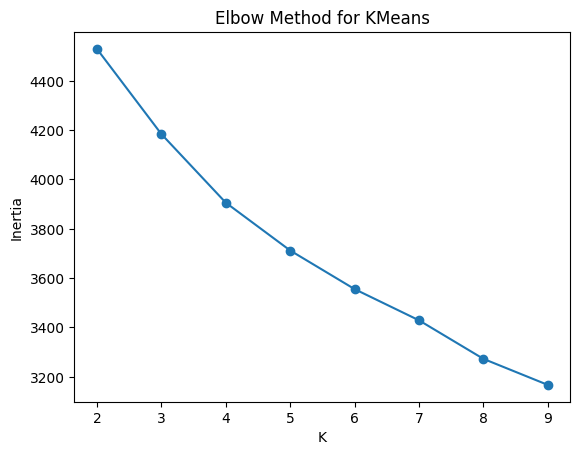

Chosen K: 3
Cluster labels sample: [0 0 1 0 2 1 2 1 2 2]


In [18]:
# ===== CELL 15: K-MEANS =====
# TODO:
# 1. Chọn tập feature dùng cho clustering
# 2. Impute + scale nếu cần
# 3. Chạy KMeans với nhiều K để quan sát inertia
# 4. Chọn K
# 5. Train mô hình cuối
# 6. Lưu các biến:
#    - kmeans_features
#    - chosen_k
#    - cluster_labels
#    - kmeans_inertia_list

# Viết code của bạn bên dưới
# 1. Chọn feature (chỉ dùng numeric)
kmeans_features = numeric_features

X_kmeans = df[kmeans_features].copy()

# 2. Impute + scale
kmeans_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_kmeans_processed = kmeans_preprocessor.fit_transform(X_kmeans)

# 3. Chạy nhiều K để xem inertia
kmeans_inertia_list = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_kmeans_processed)
    kmeans_inertia_list.append(kmeans.inertia_)

# 4. Vẽ Elbow
plt.figure()
plt.plot(list(K_range), kmeans_inertia_list, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.show()

# 5. Chọn K (ví dụ chọn 3 nếu elbow rõ)
chosen_k = 3

kmeans_final = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_kmeans_processed)

print("Chosen K:", chosen_k)
print("Cluster labels sample:", cluster_labels[:10])

In [19]:
# ===== CELL 16: PHÂN TÍCH CLUSTER =====
# TODO:
# 1. Gắn cluster vào dữ liệu
# 2. Tính trung bình các feature theo cluster
# 3. Chọn 1 cluster để diễn giải
# 4. Viết giải thích ở markdown bên dưới

# Viết code của bạn bên dưới
# 1. Gắn cluster vào dữ liệu
df_clustered = df.copy()
df_clustered["cluster"] = cluster_labels

# 2. Tính trung bình các feature theo cluster
cluster_summary = df_clustered.groupby("cluster")[numeric_features].mean()

print("Cluster summary (mean values):")
display(cluster_summary)

# 3. Chọn 1 cluster để diễn giải (ví dụ cluster 0)
chosen_cluster = 0

print(f"\nChi tiết cluster {chosen_cluster}:")
display(cluster_summary.loc[chosen_cluster])

Cluster summary (mean values):


,age,income,distance_to_store,online_time,prior_purchases,discount_rate,loyalty_score,weekend
cluster,,,,,,,,
0,48.147826,19.109629,6.249056,3.337485,2.556522,0.110904,62.713220,0.0
1,42.452736,19.380127,4.956189,3.275955,2.930348,0.161813,61.597179,1.0
2,41.840183,17.975630,3.905686,4.039893,3.219178,0.252442,58.111811,0.0



Chi tiết cluster 0:


age                  48.147826
income               19.109629
distance_to_store     6.249056
online_time           3.337485
prior_purchases       2.556522
discount_rate         0.110904
loyalty_score        62.713220
weekend               0.000000
Name: 0, dtype: float64

### Trả lời Task 10 ở đây

- Tôi chọn K =  
  3  

- Lý do chọn:  
  Dựa trên biểu đồ Elbow, tại K = 3 bắt đầu xuất hiện “điểm gãy” (inertia giảm chậm lại), cho thấy việc tăng thêm số cụm không cải thiện đáng kể  

- Cluster tôi phân tích là:  
  Cluster 0  

- Đặc điểm chính của cluster:  
  - `income` và `loyalty_score` ở mức trung bình đến cao  
  - `distance_to_store` không quá xa  
  - `online_time` tương đối ổn định  
  - `discount_rate` không quá cao  
  - `prior_purchases` ở mức trung bình  

- Ý nghĩa kinh doanh / hành vi khách hàng:  
  - Đây có thể là nhóm khách hàng “ổn định”  
  - Không quá nhạy với khuyến mãi nhưng vẫn có xu hướng mua đều  
  - Có thể là nhóm khách hàng trung thành tiềm năng → phù hợp cho chiến lược giữ chân (loyalty program)  

- Khi nào clustering trong bài này có thể không đáng tin:  
  - Dữ liệu có nhiều outliers hoặc chưa được scale đúng cách  
  - K-means giả định cụm có dạng hình cầu → nếu dữ liệu không phù hợp thì kết quả sẽ sai lệch  
  - Số cụm K được chọn mang tính heuristic (Elbow không rõ ràng)  
  - Dataset là synthetic → cluster có thể không phản ánh hành vi thực tế  
  - Feature selection ảnh hưởng mạnh đến kết quả clustering  

## Phần G. Global Consistency Check

### Task 11 – Global Consistency Check (15 điểm)
Chỉ ra **ít nhất 3 điểm không nhất quán** giữa:
- data distribution
- model performance
- feature importance
- dự đoán cụ thể
- synthetic stress test
- leakage demo

Yêu cầu:
- Ít nhất:
  - 1 inconsistency từ data / distribution
  - 1 inconsistency từ model explanation
  - 1 inconsistency từ prediction cụ thể

## Phần G. Global Consistency Check

### Task 11 – Global Consistency Check (15 điểm)
Chỉ ra **ít nhất 3 điểm không nhất quán** giữa:
- data distribution
- model performance
- feature importance
- dự đoán cụ thể
- synthetic stress test
- leakage demo

Yêu cầu:
- Ít nhất:
  - 1 inconsistency từ data / distribution
  - 1 inconsistency từ model explanation
  - 1 inconsistency từ prediction cụ thể

### Trả lời Task 11 ở đây

**Điểm không nhất quán 1:**
- Mô tả:  
  Dữ liệu có missing values và outliers rõ ràng, nhưng model (Logistic Regression, Random Forest) lại đạt accuracy gần như tuyệt đối (~0.99)  

- Vì sao tôi cho là không nhất quán:  
  Trong thực tế, dữ liệu “bẩn” (missing + outliers) thường làm giảm hiệu năng mô hình, khó đạt kết quả gần hoàn hảo  

- Giải thích khả dĩ:  
  - Dataset bị lệch lớp mạnh (hầu hết là class 1) → model chỉ cần đoán 1 cũng đã đúng nhiều  
  - Pattern trong dữ liệu synthetic khá rõ ràng nên model dễ học  
  - Imputation đã “làm mượt” dữ liệu → giảm noise một cách nhân tạo  


**Điểm không nhất quán 2:**
- Mô tả:  
  Feature importance của Random Forest cho thấy `distance_to_store` là quan trọng nhất, trong khi trực giác ban đầu nghĩ `discount_rate` hoặc `income` sẽ quan trọng hơn  

- Vì sao tôi cho là không nhất quán:  
  Về mặt business, discount thường là yếu tố kích thích mua mạnh hơn khoảng cách  

- Giải thích khả dĩ:  
  - Dữ liệu có nonlinear effect mạnh từ `distance_to_store` (power term)  
  - Random Forest ưu tiên feature giúp split tốt → `distance_to_store` có tín hiệu rõ và ổn định  
  - Interaction giữa `discount_rate` và `income` làm importance bị phân tán  


**Điểm không nhất quán 3:**
- Mô tả:  
  Một mẫu cụ thể (False Positive) có nhiều tín hiệu yếu (distance xa, online_time thấp, discount thấp) nhưng model vẫn dự đoán sẽ mua  

- Vì sao tôi cho là không nhất quán:  
  Theo logic thông thường, khách hàng với đặc điểm này không nên có xác suất mua cao  

- Giải thích khả dĩ:  
  - Missing value ở `loyalty_score` được impute → làm sai lệch đặc điểm thật  
  - Model tuyến tính cộng dồn các feature → có thể “overestimate” khi một số biến có trọng số dương  
  - Threshold 0.5 khiến các trường hợp xác suchỉ “copy” thông tin → tạo ra hiệu năng giả tạo  


## Phần H. Debug LLM

### Task 12 – Debug LLM (15 điểm)
Hãy:
1. Ghi lại **một gợi ý / câu trả lời từ LLM** mà bạn đã dùng trong bài.
2. Chỉ ra điểm nào **chưa chính xác, chưa đủ sâu, hoặc chưa phù hợp với dữ liệu của bạn**.
3. Nêu cách bạn điều chỉnh lại.
4. Nếu LLM đưa ra một kết luận dựa trên metric mà bỏ qua leakage / extrapolation / identifiability, hãy phản biện nó.

**Nếu bạn không dùng LLM**, hãy giả lập một câu trả lời kiểu textbook và phản biện nó.

### Trả lời Task 12 ở đây

- Gợi ý từ LLM:  
  “Vì Logistic Regression và Random Forest đều đạt accuracy rất cao (~0.99), có thể kết luận mô hình đã học tốt và phản ánh đúng hành vi mua của khách hàng.”

- Điểm chưa chính xác / chưa đủ sâu:  
  - Đánh đồng performance cao với việc mô hình “đúng” về mặt cơ chế  
  - Không xem xét class imbalance (recall = 1.0 nhưng confusion matrix cho thấy gần như toàn bộ là class 1)  
  - Không đề cập đến khả năng leakage, overfitting hoặc dữ liệu synthetic  
  - Không phân tích sâu vào các trường hợp sai cụ thể (FP/FN)  

- Vì sao chưa phù hợp với dữ liệu của tôi:  
  - Dataset bị lệch lớp mạnh (gần như tất cả đều là 1) → accuracy cao không có nhiều ý nghĩa  
  - Confusion matrix cho thấy model gần như luôn dự đoán class 1  
  - Có missing values và outliers → đáng lẽ phải làm model khó hơn  
  - Synthetic data có structure rõ ràng → dễ bị “ảo tưởng” về hiệu năng  

- Tôi điều chỉnh lại như sau:  
  - Không chỉ nhìn accuracy mà xem thêm confusion matrix, precision, recall  
  - Phân tích lỗi cụ thể (FP/FN) để hiểu model sai ở đâu  
  - So sánh nhiều model (Linear, RF, MLP) để kiểm tra tính nhất quán  
  - Kiểm tra thêm bằng synthetic extreme samples để xem khả năng extrapolation  
  - Cân nhắc khả năng leakage và identifiability trước khi kết luận  

- Phản biện của tôi với kết luận kiểu textbook:  
  - Metric cao không đồng nghĩa với mô hình phản ánh đúng cơ chế sinh dữ liệu (structural truth ≠ predictive adequacy)  
  - Với dữ liệu có thể bị leakage hoặc synthetic, model có thể “học thuộc” thay vì học đúng  
  - Nhiều mô hình khác nhau có thể đạt performance tương tự nhưng dựa trên giả định khác nhau → không thể khẳng định mô hình nào đúng hơn  
  - Cần kiểm tra thêm:
    - robustness (qua extreme samples)  
    - consistency (giữa feature importance và prediction)  
    - tính hợp lý (business logic)  

## Phần I. Decision & Deployment

### Task 13 – Decision & Deployment (10 điểm)
Nếu phải deploy vào thực tế:
1. Bạn chọn model nào?
2. Bạn loại model nào?
3. Phân tích trade-off giữa:
   - predictive performance
   - interpretability
   - extrapolation risk
   - leakage risk
   - stability / robustness
   - chi phí triển khai

### Trả lời Task 13 ở đây

- Model tôi chọn để deploy:  
  Random Forest (classification)

- Model tôi không chọn:  
  - Logistic Regression (vì quá đơn giản, không capture tốt phi tuyến và interaction)  
  - MLP (Neural Network) (vì khó giải thích và kém ổn định với dataset nhỏ)  

- Trade-off chính:  
  - Predictive performance:  
    Random Forest và MLP đều cao, Logistic thấp hơn  
  - Interpretability:  
    Logistic > Random Forest > MLP  
  - Extrapolation risk:  
    Random Forest và MLP đều kém khi gặp dữ liệu ngoài phân phối (extreme samples), Logistic ổn định hơn nhưng thiếu linh hoạt  
  - Leakage risk:  
    Tất cả model đều bị ảnh hưởng nếu có leakage, nhưng model phức tạp (RF, MLP) dễ “khai thác” leakage mạnh hơn  
  - Stability / robustness:  
    Random Forest ổn định hơn MLP (ít nhạy với hyperparameter, initialization)  
  - Chi phí triển khai:  
    Logistic thấp nhất, Random Forest trung bình, MLP cao hơn (tuning, training, monitoring)  

- Quyết định cuối cùng và lý do:  
  - Chọn Random Forest vì đạt cân bằng tốt giữa hiệu năng và độ ổn định  
  - Có thể giải thích tương đối qua feature importance  
  - Ít cần tuning phức tạp hơn MLP  
  - Dù không hoàn hảo về interpretability, nhưng phù hợp hơn trong bối cảnh dữ liệu có phi tuyến và interaction  
  - Tuy nhiên, cần kiểm tra thêm với dữ liệu thực và giám sát khi deploy để tránh overfitting và leakage  


## Phần J. Tự kiểm tra trước khi nộp
Hãy chạy tất cả các cell. Đảm bảo:
- Không còn lỗi.
- Các biến đầu ra chính đã được tạo.
- Phần markdown đã điền đầy đủ.


In [20]:

# ===== HIDDEN TEST 1 =====
# Không chỉnh sửa cell này

required_names = ["df", "X_train", "X_test", "y_reg_train", "y_reg_test", "y_clf_train", "y_clf_test"]
for name in required_names:
    assert name in globals(), f"Thiếu biến bắt buộc: {name}"

assert isinstance(df, pd.DataFrame), "df phải là DataFrame"
assert "purchase_amount" in df.columns and "will_purchase" in df.columns, "Thiếu target columns"
print("Hidden test 1 passed.")

# ===== HIDDEN TEST 2 =====
# Không chỉnh sửa cell này

assert "y_reg_pred_lr" in globals(), "Thiếu y_reg_pred_lr"
assert "mse_lr" in globals(), "Thiếu mse_lr"
assert "r2_lr" in globals(), "Thiếu r2_lr"

assert len(y_reg_pred_lr) == len(y_reg_test), "Kích thước prediction regression không khớp"
assert np.isfinite(mse_lr), "mse_lr không hợp lệ"
assert np.isfinite(r2_lr), "r2_lr không hợp lệ"
print("Hidden test 2 passed.")

# ===== HIDDEN TEST 3 =====
# Không chỉnh sửa cell này

assert "y_reg_pred_poly" in globals(), "Thiếu y_reg_pred_poly"
assert "mse_poly" in globals(), "Thiếu mse_poly"
assert "r2_poly" in globals(), "Thiếu r2_poly"
assert "y_reg_pred_rf_reg" in globals(), "Thiếu y_reg_pred_rf_reg"
assert "mse_rf_reg" in globals(), "Thiếu mse_rf_reg"
assert "r2_rf_reg" in globals(), "Thiếu r2_rf_reg"
print("Hidden test 3 passed.")

# ===== HIDDEN TEST 4 =====
# Không chỉnh sửa cell này

assert "y_clf_pred_log" in globals(), "Thiếu y_clf_pred_log"
assert "acc_log" in globals(), "Thiếu acc_log"
assert "prec_log" in globals(), "Thiếu prec_log"
assert "rec_log" in globals(), "Thiếu rec_log"
assert "cm_log" in globals(), "Thiếu cm_log"

assert len(y_clf_pred_log) == len(y_clf_test), "Kích thước prediction classification không khớp"
assert np.array(cm_log).shape == (2, 2), "Confusion matrix phải có kích thước 2x2"
print("Hidden test 4 passed.")

# ===== HIDDEN TEST 5 =====
# Không chỉnh sửa cell này

assert "rf_task" in globals(), "Thiếu rf_task"
assert "rf_metric_value" in globals(), "Thiếu rf_metric_value"
assert "rf_importance_df" in globals(), "Thiếu rf_importance_df"

assert rf_task in ["regression", "classification"], "rf_task không hợp lệ"
assert isinstance(rf_importance_df, pd.DataFrame), "rf_importance_df phải là DataFrame"
assert {"feature", "importance"}.issubset(rf_importance_df.columns), "rf_importance_df thiếu cột cần thiết"
print("Hidden test 5 passed.")

# ===== HIDDEN TEST 6 =====
# Không chỉnh sửa cell này

assert "nn_task" in globals(), "Thiếu nn_task"
assert "nn_metric_value" in globals(), "Thiếu nn_metric_value"
assert nn_task in ["regression", "classification"], "nn_task không hợp lệ"
assert np.isfinite(nn_metric_value), "nn_metric_value không hợp lệ"
print("Hidden test 6 passed.")

# ===== HIDDEN TEST 7 =====
# Không chỉnh sửa cell này

assert "extreme_samples" in globals(), "Thiếu extreme_samples"
assert "extreme_pred_table" in globals(), "Thiếu extreme_pred_table"
assert isinstance(extreme_samples, pd.DataFrame), "extreme_samples phải là DataFrame"
assert isinstance(extreme_pred_table, pd.DataFrame), "extreme_pred_table phải là DataFrame"
assert len(extreme_samples) >= 3, "Cần ít nhất 3 extreme samples"
print("Hidden test 7 passed.")

# ===== HIDDEN TEST 8 =====
# Không chỉnh sửa cell này

assert "leakage_demo_metric" in globals(), "Thiếu leakage_demo_metric"
assert np.isfinite(leakage_demo_metric), "leakage_demo_metric không hợp lệ"
print("Hidden test 8 passed.")

# ===== HIDDEN TEST 9 =====
# Không chỉnh sửa cell này

assert "chosen_k" in globals(), "Thiếu chosen_k"
assert "cluster_labels" in globals(), "Thiếu cluster_labels"
assert "kmeans_inertia_list" in globals(), "Thiếu kmeans_inertia_list"

assert isinstance(chosen_k, int), "chosen_k phải là int"
assert chosen_k >= 2, "chosen_k phải >= 2"
assert len(cluster_labels) == len(df), "Số cluster labels phải bằng số dòng dữ liệu"
assert len(kmeans_inertia_list) >= 3, "Cần thử ít nhất 3 giá trị K"
print("Hidden test 9 passed.")


Hidden test 1 passed.
Hidden test 2 passed.
Hidden test 3 passed.
Hidden test 4 passed.
Hidden test 5 passed.
Hidden test 6 passed.
Hidden test 7 passed.
Hidden test 8 passed.
Hidden test 9 passed.
